# Project 2: Reproducibility in Natural Language Processing



### Read Data

In [8]:
# imports
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-dark')

In [9]:
# To save our figures
from pathlib import Path
outputs_dir = Path('outputs')

In [10]:
sou = pd.read_csv("data/SOTU.csv")

In [11]:
!pip install spacy
!pip install pyLDAvis
!pip install gensim
!pip install bertopic
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 72.9 MB/s eta 0:00:0000:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [12]:
import spacy
from tqdm import tqdm
from collections import Counter

nlp = spacy.load("en_core_web_sm")

## Part 3: Advanced Text Processing - LDA and BERTopic Topic Modeling (20 pts)

**Resources:**
- LDA:
    - https://medium.com/sayahfares19/text-analysis-topic-modelling-with-spacy-gensim-4cd92ef06e06 
    - https://www.kaggle.com/code/faressayah/text-analysis-topic-modeling-with-spacy-gensim#%F0%9F%93%9A-Topic-Modeling (code for previous post)
    - https://towardsdatascience.com/topic-modelling-in-python-with-spacy-and-gensim-dc8f7748bdbf/ 
- BERTopic:
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_documents.html#visualize-documents-with-plotly 
    - https://maartengr.github.io/BERTopic/getting_started/visualization/visualize_topics.html 


In [5]:
from spacy import displacy
from bertopic import BERTopic
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from sklearn.feature_extraction.text import CountVectorizer
import pyLDAvis
import pyLDAvis.gensim_models

### LDA

- Train an LDA model with 18 topics
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization

You may use the next two cells to process the data.

In [13]:
def preprocess_text(text): 
    doc = nlp(text) 
    return [token.lemma_.lower() for token in doc if not token.is_stop and not token.is_punct and not token.is_space and len(token.lemma_) > 3]

In [14]:
# Process all texts - note this takes ~ 5 minutes to run
processed_docs = sou['Text'].apply(preprocess_text)

In [15]:
processed_docs.head()

0    [speak, president, present, prepared, remark, ...
1    [president, speaker, point, president, turn, f...
2    [president, thank, thank, thank, madam, speake...
3    [president, thank, thank, thank, good, mitch, ...
4    [president, thank, thank, thank, madam, speake...
Name: Text, dtype: object

To train an LDA model, use the LdaModel function that we imported a couple of cells back. The last resource linked under the LDA section is especially useful for walking through the steps we have below. *Note: one of the arguments to the LdaModel function is `random_state` which specifies the random seed for reproducibility. Please set yours to 42. Further, the last resource provided uses `LdaMulticore` which is essentially a parallelizable version of our function `LdaModel`. Use `LdaModel` instead, but the usage will be similar, except you can ignore the `iterations` and `workers` arguments..*.

In [17]:
# Build dictionary from processed_docs, which is a list of tokens extracted from our speeches
texts_tokens = processed_docs.tolist()
dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in texts_tokens]

In [18]:
# train LDA model with 18 topics
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=18,
    random_state=42,
    passes=10
)

In [19]:
# print the top 10 words for each topic
for idx, topic in lda_model.print_topics(num_topics=18, num_words=10):
    print(f"Topic {idx}:\n{topic}\n")

Topic 0:
0.008*"canal" + 0.005*"tariff" + 0.004*"panama" + 0.004*"statute" + 0.004*"company" + 0.004*"method" + 0.004*"convention" + 0.003*"board" + 0.003*"cent" + 0.003*"china"

Topic 1:
0.003*"mexico" + 0.001*"texas" + 0.001*"mexican" + 0.001*"convention" + 0.001*"americans" + 0.001*"minister" + 0.001*"program" + 0.001*"article" + 0.001*"cent" + 0.001*"loan"

Topic 2:
0.006*"method" + 0.005*"board" + 0.005*"agricultural" + 0.005*"farmer" + 0.005*"cent" + 0.004*"farm" + 0.004*"project" + 0.004*"veteran" + 0.004*"depression" + 0.004*"committee"

Topic 3:
0.004*"cent" + 0.004*"gold" + 0.004*"silver" + 0.003*"indian" + 0.003*"june" + 0.003*"bond" + 0.003*"method" + 0.003*"island" + 0.002*"conference" + 0.002*"tariff"

Topic 4:
0.019*"spain" + 0.009*"article" + 0.007*"minister" + 0.006*"likewise" + 0.005*"manufacture" + 0.005*"port" + 0.005*"tribe" + 0.005*"intercourse" + 0.004*"presume" + 0.004*"colony"

Topic 5:
0.009*"tariff" + 0.008*"corporation" + 0.007*"evil" + 0.006*"cable" + 0.005

In [22]:
# print the topic distribution for the first speech
first_speech_bow = corpus[0]
lda_model.get_document_topics(first_speech_bow)

[(7, 0.99942523)]

In [24]:
# make a visualization using pyLDAvis
pyLDAvis.enable_notebook()
lda_vis = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(lda_vis, "outputs/lda_topics.html")
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
16     0.124684 -0.016058       1        1  23.654732
3      0.047043  0.069631       2        1  22.186784
7     -0.249568 -0.032435       3        1  16.493399
15    -0.148444  0.093409       4        1  12.985501
0      0.042368  0.115060       5        1   6.480904
12     0.140061 -0.005773       6        1   6.077240
2     -0.028744  0.157597       7        1   3.946297
14     0.115200  0.048899       8        1   2.810770
10     0.072309  0.026057       9        1   2.145181
4      0.168740 -0.086130      10        1   1.301693
6     -0.162808 -0.128171      11        1   0.610863
5     -0.012308  0.061678      12        1   0.486734
9     -0.084382  0.041350      13        1   0.414859
17     0.051993 -0.138049      14        1   0.284723
13     0.022478 -0.077904      15        1   0.108571
1     -0.025788 -0.039226      16        1   0.003917
8     -0.027274 -0.044925      17        1   0.003917
11    -0.045561 -0.045010      18        1   0.003917, topic_info=           Term         Freq        Total Category  logprob  loglift
31    americans   983.000000   983.000000  Default  30.0000  30.0000
509     program  1305.000000  1305.000000  Default  29.0000  29.0000
665     tonight   654.000000   654.000000  Default  28.0000  28.0000
976      mexico   820.000000   820.000000  Default  27.0000  27.0000
656       thank   374.000000   374.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
1653       area     0.006954   441.112509  Topic18  -7.5829  -0.9100
737      worker     0.006925   457.650212  Topic18  -7.5871  -0.9510
3016    surplus     0.006855   448.041454  Topic18  -7.5973  -0.9400
407    minister     0.006909   556.406340  Topic18  -7.5894  -1.1487
2169     island     0.006898   582.756261  Topic18  -7.5910  -1.1966

[1340 rows x 6 columns], token_table=      Topic      Freq   Term
term                        
5548      4  0.188489   -the
5548      6  0.188489   -the
5548      8  0.376977   -the
5548     13  0.188489   -the
7117      1  0.908818   1794
...     ...       ...    ...
742       9  0.026307  young
742      11  0.016442  young
742      12  0.006577  young
742      13  0.003288  young
6556      2  0.910577  yukon

[5421 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[17, 4, 8, 16, 1, 13, 3, 15, 11, 5, 7, 6, 10, 18, 14, 2, 9, 12])

### BERTopic

- Train a BERTopic model with a `min_topic_size` of 3 *Hint: use `BERTopic` to instantiate the model and specify `min_topic_size` in here. Actually fit the model using `fit_transform`, which `docs` passed into this.*
- Output the top 10 words for each topic. 
- Output the topic distribution for the first speech
- Make a visualization of the topics (see topic_model.visualize_topics())

In [85]:
docs = sou['Text'].to_list()

In [86]:
# train the model - this takes about 30 seconds

# remove stop words from the topics (Hint: use CountVectorizer and then .update_topics on topic_model)

2025-11-08 22:50:56,658 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 8/8 [00:08<00:00,  1.03s/it]
2025-11-08 22:51:09,053 - BERTopic - Embedding - Completed ✓
2025-11-08 22:51:09,054 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-08 22:51:19,326 - BERTopic - Dimensionality - Completed ✓
2025-11-08 22:51:19,327 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-08 22:51:19,342 - BERTopic - Cluster - Completed ✓
2025-11-08 22:51:19,346 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-08 22:51:20,853 - BERTopic - Representation - Completed ✓


In [87]:
# output the top 10 words for each topic - hint see get_topic_info

,Topic,Count,Name,Representation,Representative_Docs
0,-1,56,-1_states_government_united_congress,"[states, government, united, congress, country...",[\nTo the Congress of the United States:\nYour...
1,0,29,0_world_people_new_years,"[world, people, new, years, america, american,...","[\nMr. Speaker, Mr. President, my colleagues i..."
2,1,18,1_america_americans_american_people,"[america, americans, american, people, tonight...","[\nMr. Speaker, Vice President Cheney, Members..."
3,2,17,2_states_government_united_congress,"[states, government, united, congress, public,...",[\nTo the Senate and House of Representatives ...
4,3,15,3_states_government_united_law,"[states, government, united, law, congress, ye...",[\nTo the Senate and House of Representatives:...
5,4,12,4_government_work_public_congress,"[government, work, public, congress, great, la...",[\nTo the Senate and House of Representatives:...
6,5,11,5_world_peace_nations_soviet,"[world, peace, nations, soviet, nation, econom...","[\nMr. President, Mr. Speaker, Members of the ..."
7,6,9,6_british_states_united_war,"[british, states, united, war, enemy, great, f...",[\nFellow-Citizens of the Senate and House of ...
8,7,8,7_states_government_congress_united,"[states, government, congress, united, year, c...",[\nFellow-Citizens of the Senate and House of ...
9,8,8,8_america_americans_jobs_new,"[america, americans, jobs, new, american, that...","[\nMadam Speaker, Mr. Vice President, Members ..."


100%|██████████| 1/1 [00:14<00:00, 14.91s/it]


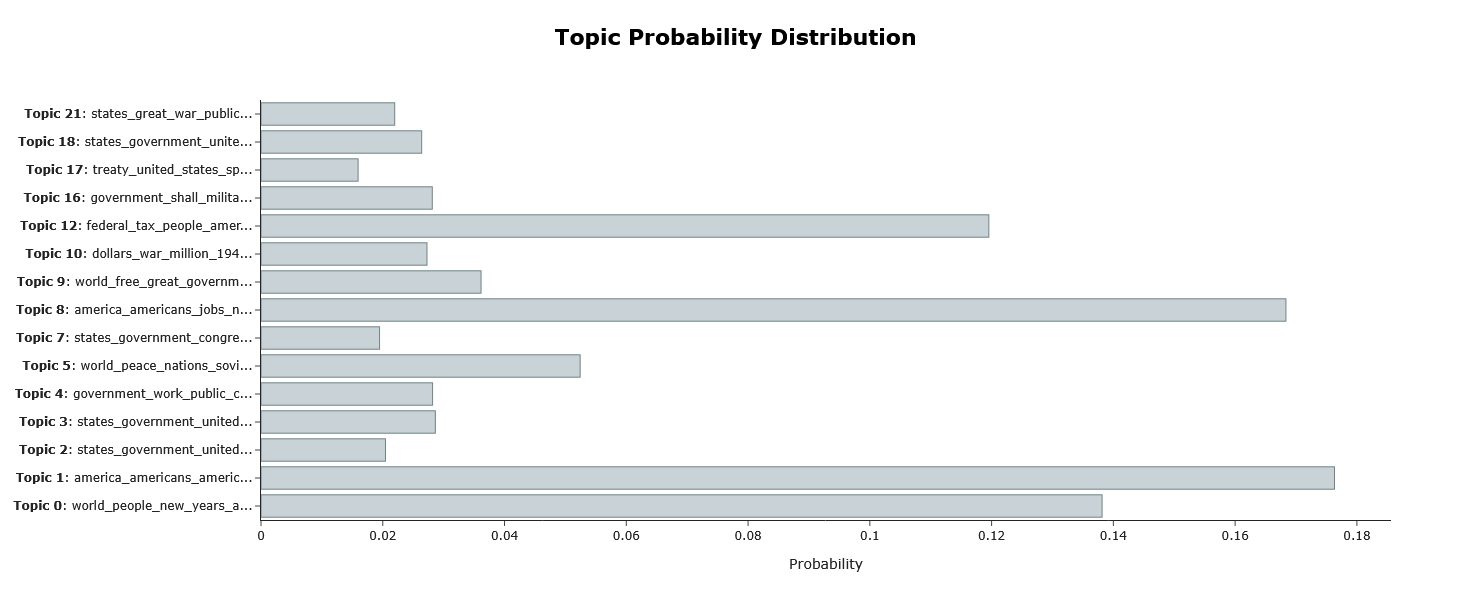

In [88]:
# output the topic distribution for the first speech
# hint: check out approximate_distribution() and visualize_distribution()

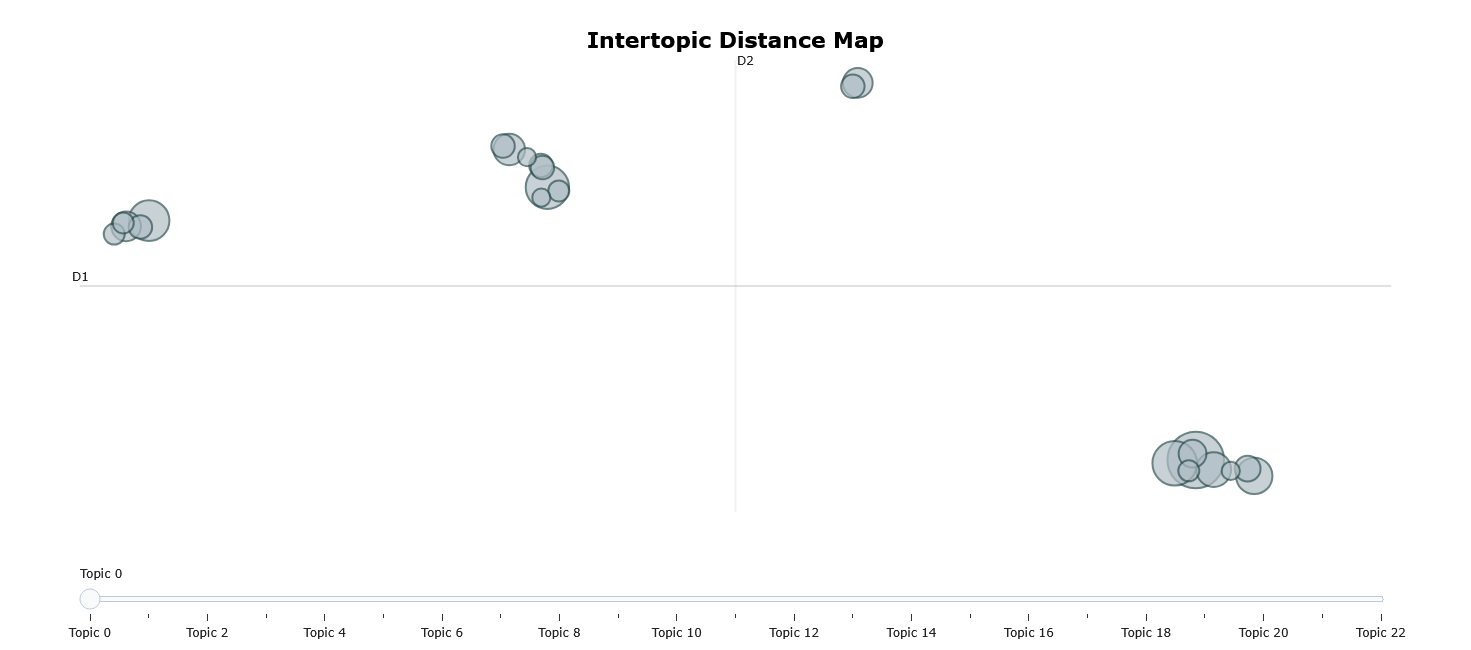

In [90]:
# run this cell to visualize the topics
topic_model.visualize_topics()